# Monte-Carlo Control для Taxi

Сделать:

1. Применить любой алгоритм Монте-Карло к среде Taxi.
2. Запустить несколько эпизодов и вывести состояния, действия и награды.
3. Проанализировать, какие действия чаще встречаются в успешных эпизодах.
4. Изменить поведенческую стратегию так, чтобы агент чаще выбирал действия,
   связанные с успешными траекториями.

В работе используется **First-Visit Monte-Carlo Control** с `е-greedy` стратегией.

После первого обучения строится статистика успешных эпизодов, затем
исследовательская часть стратегии изменяется с учётом этой статистики.

## Среда Taxi

В Taxi есть:

- 500 закодированных состояний;
- 6 действий;
- `-1` за обычный шаг;
- `-10` за незаконную посадку или высадку;
- `+20` за успешную высадку пассажира.

Действия:

```text
0 — South
1 — North
2 — East
3 — West
4 — Pickup
5 — Dropoff
```

## Установка

In [1]:
%pip install -q "gymnasium>=1.0,<2"

## Импорты

In [2]:
# Импорты

from collections import Counter

import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


SEED = 42

np.random.seed(
    SEED
)


print(
    "Gymnasium:",
    gym.__version__
)

Gymnasium: 1.3.0


## Создание среды

In [3]:
# Среда Taxi

try:
    ENV_ID = "Taxi-v3"

    env = gym.make(
        ENV_ID
    )

except Exception:
    # Fallback для новых версий Gymnasium.
    ENV_ID = "Taxi-v4"

    env = gym.make(
        ENV_ID
    )


N_STATES = (
    env.observation_space.n
)

N_ACTIONS = (
    env.action_space.n
)


ACTION_NAMES = {
    0: "South",
    1: "North",
    2: "East",
    3: "West",
    4: "Pickup",
    5: "Dropoff",
}


print(
    "Среда:",
    ENV_ID
)

print(
    "Состояний:",
    N_STATES
)

print(
    "Действий:",
    N_ACTIONS
)

print(
    ACTION_NAMES
)

Среда: Taxi-v4
Состояний: 500
Действий: 6
{0: 'South', 1: 'North', 2: 'East', 3: 'West', 4: 'Pickup', 5: 'Dropoff'}


/usr/local/lib/python3.13/dist-packages/gymnasium/envs/registration.py:513: DeprecationWarning: WARN: The environment Taxi-v3 is out of date. You should consider upgrading to version `v4`.
  logger.deprecation(


## Расшифровка состояния

Состояние Taxi — одно целое число.

Для удобства дополнительно расшифровываем его в:

```text
taxi_row
taxi_col
passenger
destination
```

In [4]:
# Расшифровка состояния

def decode_state(
    state,
):
    decoded = list(
        env.unwrapped.decode(
            int(
                state
            )
        )
    )

    return {
        "taxi_row": decoded[0],
        "taxi_col": decoded[1],
        "passenger": decoded[2],
        "destination": decoded[3],
    }

Большую часть времени выбираем действие с максимальным `Q(s, a)`,
но с вероятностью `ε` исследуем другие действия.

В первом эксперименте исследовательское действие выбирается равномерно.

In [5]:
# Вероятности действий

def action_probabilities(
    Q,
    state,
    epsilon,
    action_prior=None,
):

    if action_prior is None:

        exploration = np.ones(
            N_ACTIONS,
            dtype=np.float64,
        )

    else:

        exploration = np.asarray(
            action_prior,
            dtype=np.float64,
        ).copy()


    exploration = np.maximum(
        exploration,
        1e-8,
    )


    exploration /= (
        exploration.sum()
    )


    probabilities = (
        epsilon
        * exploration
    )


    best_action = int(
        np.argmax(
            Q[
                state
            ]
        )
    )


    probabilities[
        best_action
    ] += (
        1.0
        - epsilon
    )


    return probabilities

In [6]:
# Выбор действия

def choose_action(
    Q,
    state,
    epsilon,
    action_prior=None,
):

    probabilities = (
        action_probabilities(
            Q,
            state,
            epsilon,
            action_prior,
        )
    )


    action = np.random.choice(
        N_ACTIONS,
        p=probabilities,
    )


    return int(
        action
    )

## Генерация одного эпизода

Сохраняем для каждого шага:

```text
state
action
reward
next_state
```

Это понадобится и для Monte-Carlo update, и для анализа.

In [7]:
# Один эпизод

def generate_episode(
    Q,
    epsilon,
    action_prior=None,
    seed=None,
    max_steps=200,
):

    state, info = env.reset(
        seed=seed
    )


    episode = []

    total_reward = 0.0

    success = False


    for step in range(
        max_steps
    ):

        action = choose_action(
            Q,
            state,
            epsilon,
            action_prior,
        )


        (
            next_state,
            reward,
            terminated,
            truncated,
            info,
        ) = env.step(
            action
        )


        episode.append(
            {
                "state": int(
                    state
                ),

                "action": int(
                    action
                ),

                "reward": float(
                    reward
                ),

                "next_state": int(
                    next_state
                ),
            }
        )


        total_reward += float(
            reward
        )


        state = next_state


        if terminated:
            success = True


        if (
            terminated
            or truncated
        ):
            break


    return (
        episode,
        total_reward,
        success,
    )

## First-Visit Monte-Carlo update

После завершения эпизода вычисляем доход:

```text
G = r(t+1) + γr(t+2) + ...
```

и обновляем `Q(s, a)` только для первого посещения пары
`state-action` в данном эпизоде.

In [8]:
# Обновление Q

def first_visit_mc_update(
    Q,
    visit_count,
    episode,
    gamma=0.99,
):

    returns = np.zeros(
        len(
            episode
        ),
        dtype=np.float64,
    )


    G = 0.0


    for index in range(
        len(
            episode
        )
        - 1,
        -1,
        -1,
    ):

        G = (
            episode[
                index
            ][
                "reward"
            ]
            + gamma
            * G
        )


        returns[
            index
        ] = G


    visited = set()


    for index, transition in enumerate(
        episode
    ):

        state = transition[
            "state"
        ]

        action = transition[
            "action"
        ]


        pair = (
            state,
            action,
        )


        if pair in visited:
            continue


        visited.add(
            pair
        )


        visit_count[
            state,
            action,
        ] += 1


        count = visit_count[
            state,
            action,
        ]


        Q[
            state,
            action,
        ] += (
            returns[
                index
            ]
            - Q[
                state,
                action
            ]
        ) / count

## Обучение Monte-Carlo Control

Во время обучения постепенно уменьшаем `Е`:

```text
0.30 -> 0.05
```

В начале агент больше исследует среду, а ближе к концу чаще использует
уже найденные хорошие действия.

In [9]:
# Monte-Carlo Control

def train_mc_control(
    n_episodes,
    action_prior=None,
    gamma=0.99,
    epsilon_start=0.30,
    epsilon_min=0.05,
    epsilon_decay=0.9998,
    seed_offset=0,
):

    Q = np.zeros(
        (
            N_STATES,
            N_ACTIONS,
        ),
        dtype=np.float64,
    )


    visit_count = np.zeros(
        (
            N_STATES,
            N_ACTIONS,
        ),
        dtype=np.int64,
    )


    rewards = []

    successes = []

    training_episodes = []


    epsilon = (
        epsilon_start
    )


    for episode_index in range(
        n_episodes
    ):

        episode, total_reward, success = (
            generate_episode(
                Q=Q,
                epsilon=epsilon,
                action_prior=action_prior,
                seed=(
                    SEED
                    + seed_offset
                    + episode_index
                ),
            )
        )


        first_visit_mc_update(
            Q,
            visit_count,
            episode,
            gamma=gamma,
        )


        rewards.append(
            total_reward
        )

        successes.append(
            int(
                success
            )
        )


        # Сохраняем эпизоды для анализа.
        training_episodes.append(
            {
                "steps": episode,
                "reward": total_reward,
                "success": success,
            }
        )


        epsilon = max(
            epsilon_min,
            epsilon
            * epsilon_decay,
        )


        if (
            episode_index == 0
            or (
                episode_index + 1
            ) % 5000 == 0
        ):

            recent_success = np.mean(
                successes[
                    -1000:
                ]
            )


            print(
                f"Эпизод "
                f"{episode_index + 1:5d} | "
                f"epsilon={epsilon:.3f} | "
                f"success(last 1000)="
                f"{recent_success:.3f}"
            )


    return {
        "Q": Q,
        "visit_count": visit_count,
        "rewards": np.asarray(
            rewards
        ),
        "successes": np.asarray(
            successes
        ),
        "episodes": training_episodes,
    }

## Первое обучение: обычная ε-greedy стратегия

In [10]:
# Базовое обучение

N_EPISODES = 30000


baseline = train_mc_control(
    n_episodes=N_EPISODES,
)

Эпизод     1 | epsilon=0.300 | success(last 1000)=0.000
Эпизод  5000 | epsilon=0.110 | success(last 1000)=0.426
Эпизод 10000 | epsilon=0.050 | success(last 1000)=0.432
Эпизод 15000 | epsilon=0.050 | success(last 1000)=0.456
Эпизод 20000 | epsilon=0.050 | success(last 1000)=0.466
Эпизод 25000 | epsilon=0.050 | success(last 1000)=0.479
Эпизод 30000 | epsilon=0.050 | success(last 1000)=0.482


## График обучения

In [11]:
# Скользящее среднее

def moving_average(
    values,
    window=1000,
):

    values = np.asarray(
        values,
        dtype=np.float64,
    )


    if len(values) < window:
        return values


    kernel = np.ones(
        window
    ) / window


    return np.convolve(
        values,
        kernel,
        mode="valid",
    )

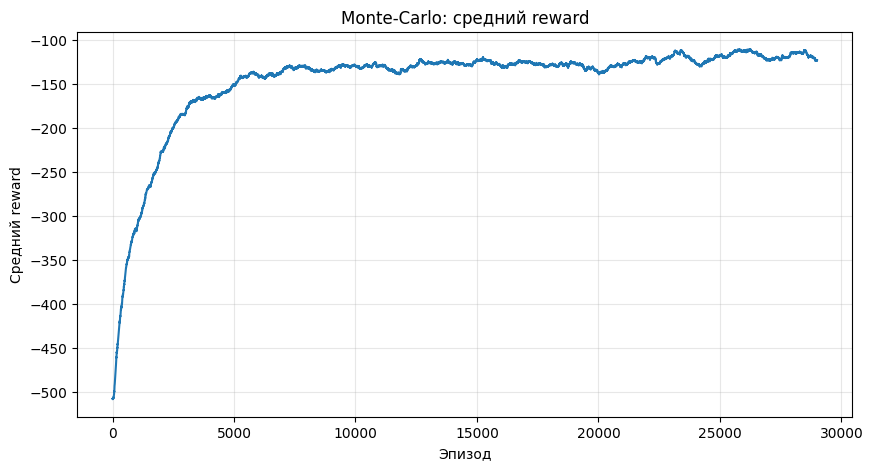

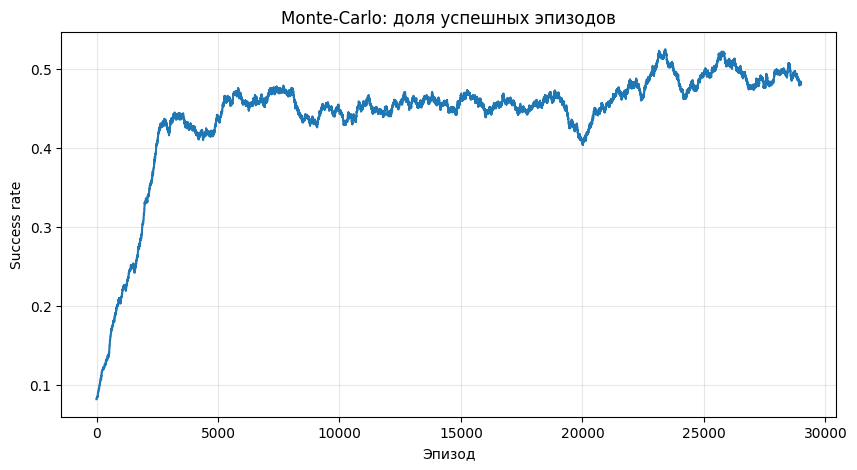

In [12]:
# Reward и success rate

reward_ma = moving_average(
    baseline[
        "rewards"
    ]
)

success_ma = moving_average(
    baseline[
        "successes"
    ]
)


plt.figure(
    figsize=(
        10,
        5,
    )
)

plt.plot(
    reward_ma
)

plt.xlabel(
    "Эпизод"
)

plt.ylabel(
    "Средний reward"
)

plt.title(
    "Monte-Carlo: средний reward"
)

plt.grid(
    alpha=0.3
)

plt.show()


plt.figure(
    figsize=(
        10,
        5,
    )
)

plt.plot(
    success_ma
)

plt.xlabel(
    "Эпизод"
)

plt.ylabel(
    "Success rate"
)

plt.title(
    "Monte-Carlo: доля успешных эпизодов"
)

plt.grid(
    alpha=0.3
)

plt.show()

## Несколько эпизодов после обучения

Запускаем жадную стратегию (`Е = 0`) и выводим
состояния, действия и награды.

In [13]:
# Таблица одного эпизода

def episode_to_dataframe(
    episode,
):

    rows = []


    for step_number, transition in enumerate(
        episode,
        start=1,
    ):

        decoded = decode_state(
            transition[
                "state"
            ]
        )


        rows.append(
            {
                "step": step_number,

                "state": transition[
                    "state"
                ],

                "taxi_row": decoded[
                    "taxi_row"
                ],

                "taxi_col": decoded[
                    "taxi_col"
                ],

                "passenger": decoded[
                    "passenger"
                ],

                "destination": decoded[
                    "destination"
                ],

                "action": transition[
                    "action"
                ],

                "action_name": (
                    ACTION_NAMES[
                        transition[
                            "action"
                        ]
                    ]
                ),

                "reward": transition[
                    "reward"
                ],

                "next_state": transition[
                    "next_state"
                ],
            }
        )


    return pd.DataFrame(
        rows
    )

In [14]:
# 3 тестовых эпизода

BASELINE_TEST_EPISODES = []


for number, seed in enumerate(
    [
        1001,
        1002,
        1003,
    ],
    start=1,
):

    episode, total_reward, success = (
        generate_episode(
            Q=baseline[
                "Q"
            ],
            epsilon=0.0,
            seed=seed,
        )
    )


    BASELINE_TEST_EPISODES.append(
        {
            "episode": episode,
            "reward": total_reward,
            "success": success,
        }
    )


    print()
    print(
        f"ЭПИЗОД {number}"
    )

    print(
        "Total reward:",
        total_reward
    )

    print(
        "Success:",
        success
    )


    display(
        episode_to_dataframe(
            episode
        )
    )


ЭПИЗОД 1
Total reward: 4.0
Success: True


,step,state,taxi_row,taxi_col,passenger,destination,action,action_name,reward,next_state
0,1,304,3,0,1,0,1,North,-1.0,204
1,2,204,2,0,1,0,2,East,-1.0,224
2,3,224,2,1,1,0,2,East,-1.0,244
3,4,244,2,2,1,0,1,North,-1.0,144
4,5,144,1,2,1,0,2,East,-1.0,164
5,6,164,1,3,1,0,2,East,-1.0,184
6,7,184,1,4,1,0,1,North,-1.0,84
7,8,84,0,4,1,0,4,Pickup,-1.0,96
8,9,96,0,4,4,0,0,South,-1.0,196
9,10,196,1,4,4,0,0,South,-1.0,296



ЭПИЗОД 2
Total reward: 4.0
Success: True


,step,state,taxi_row,taxi_col,passenger,destination,action,action_name,reward,next_state
0,1,188,1,4,2,0,3,West,-1.0,168
1,2,168,1,3,2,0,3,West,-1.0,148
2,3,148,1,2,2,0,0,South,-1.0,248
3,4,248,2,2,2,0,3,West,-1.0,228
4,5,228,2,1,2,0,1,North,-1.0,128
5,6,128,1,1,2,0,1,North,-1.0,28
6,7,28,0,1,2,0,3,West,-1.0,8
7,8,8,0,0,2,0,0,South,-1.0,108
8,9,108,1,0,2,0,0,South,-1.0,208
9,10,208,2,0,2,0,0,South,-1.0,308



ЭПИЗОД 3
Total reward: -200.0
Success: False


,step,state,taxi_row,taxi_col,passenger,destination,action,action_name,reward,next_state
0,1,91,0,4,2,3,1,North,-1.0,91
1,2,91,0,4,2,3,1,North,-1.0,91
2,3,91,0,4,2,3,1,North,-1.0,91
3,4,91,0,4,2,3,1,North,-1.0,91
4,5,91,0,4,2,3,1,North,-1.0,91
...,...,...,...,...,...,...,...,...,...,...
195,196,91,0,4,2,3,1,North,-1.0,91
196,197,91,0,4,2,3,1,North,-1.0,91
197,198,91,0,4,2,3,1,North,-1.0,91
198,199,91,0,4,2,3,1,North,-1.0,91


## Анализ действий успешных эпизодов

Посчитаем:

1. сколько раз каждое действие встречалось вообще;
2. сколько раз оно встречалось в успешных эпизодах;
3. долю успешных эпизодов среди выполнений этого действия.

Последний показатель используем как простую оценку того,
насколько действие связано с успешными траекториями.

Важно: это **глобальная статистика**. В Taxi правильность движения зависит
от конкретного состояния, поэтому нельзя сказать, что, например,
`East` всегда лучше `West`.

In [15]:
# Статистика действий

def build_action_statistics(
    episodes,
):

    total_count = Counter()

    successful_count = Counter()

    reward_sum = Counter()


    for item in episodes:

        success = item[
            "success"
        ]


        for transition in item[
            "steps"
        ]:

            action = transition[
                "action"
            ]


            total_count[
                action
            ] += 1


            reward_sum[
                action
            ] += transition[
                "reward"
            ]


            if success:

                successful_count[
                    action
                ] += 1


    rows = []


    for action in range(
        N_ACTIONS
    ):

        total = total_count[
            action
        ]

        successful = successful_count[
            action
        ]


        success_share = (
            successful / total
            if total > 0
            else 0.0
        )


        average_reward = (
            reward_sum[
                action
            ] / total
            if total > 0
            else 0.0
        )


        rows.append(
            {
                "action": action,

                "name": ACTION_NAMES[
                    action
                ],

                "all_steps": total,

                "steps_in_successful_episodes": (
                    successful
                ),

                "success_share": (
                    success_share
                ),

                "average_immediate_reward": (
                    average_reward
                ),
            }
        )


    return pd.DataFrame(
        rows
    )


action_stats = build_action_statistics(
    baseline[
        "episodes"
    ]
)


display(
    action_stats.sort_values(
        "success_share",
        ascending=False,
    )
)

,action,name,all_steps,steps_in_successful_episodes,success_share,average_immediate_reward
4,4,Pickup,115220,16849,0.146233,-6.083414
5,5,Dropoff,118745,16730,0.140890,-3.924561
1,1,North,718483,65685,0.091422,-1.000000
0,0,South,812512,62837,0.077337,-1.000000
3,3,West,941913,55944,0.059394,-1.000000
2,2,East,938829,40457,0.043093,-1.000000


In [16]:
# Самые успешные действия

best_actions = (
    action_stats
    .sort_values(
        "success_share",
        ascending=False,
    )
    .head(
        3
    )
)


print(
    "Действия с наибольшей "
    "долей успешных траекторий:"
)


for _, row in best_actions.iterrows():

    print(
        f"{int(row['action'])} "
        f"{row['name']}: "
        f"{row['success_share']:.3f}"
    )

Действия с наибольшей долей успешных траекторий:
4 Pickup: 0.146
5 Dropoff: 0.141
1 North: 0.091


### Что здесь важно

`Dropoff` — особое действие: именно корректная высадка завершает задачу
и даёт положительное вознаграждение `+20`.

`Pickup` необходим, чтобы посадить пассажира.

Движения `South / North / East / West` нельзя оценивать без состояния:
на разных клетках полезным будет разное направление.

Поэтому изменённая стратегия ниже **не заменяет Q-функцию глобальным
«лучшим действием»**, а только меняет исследовательскую часть `е-greedy`.

## Новая поведенческая стратегия

В обычной `е-greedy` при исследовании все 6 действий выбираются
с одинаковой вероятностью.

Теперь построим `success_prior`:

```text
больше success_share
        -
больше вероятность выбрать действие
во время исследования
```

При этом с вероятностью `1 - е` агент по-прежнему выбирает
лучшее действие согласно `Q(s, a)`.

In [17]:
# Приоритет успешных действий

success_scores = (
    action_stats[
        "success_share"
    ]
    .to_numpy(
        dtype=np.float64
    )
)


# Сглаживание, чтобы ни одно
# действие не получило вероятность 0.
success_scores += 0.05


success_prior = (
    success_scores
    / success_scores.sum()
)


prior_table = pd.DataFrame(
    {
        "action": range(
            N_ACTIONS
        ),

        "name": [
            ACTION_NAMES[
                action
            ]
            for action
            in range(
                N_ACTIONS
            )
        ],

        "exploration_probability": (
            success_prior
        ),
    }
)


display(
    prior_table
)

,action,name,exploration_probability
0,0,South,0.148347
1,1,North,0.164756
2,2,East,0.108453
3,3,West,0.127444
4,4,Pickup,0.228612
5,5,Dropoff,0.222387


## Второе обучение с изменённой стратегией

In [18]:
# Обучение с success-prior

improved = train_mc_control(
    n_episodes=N_EPISODES,

    action_prior=(
        success_prior
    ),

    seed_offset=100000,
)

Эпизод     1 | epsilon=0.300 | success(last 1000)=0.000
Эпизод  5000 | epsilon=0.110 | success(last 1000)=0.427
Эпизод 10000 | epsilon=0.050 | success(last 1000)=0.489
Эпизод 15000 | epsilon=0.050 | success(last 1000)=0.480
Эпизод 20000 | epsilon=0.050 | success(last 1000)=0.483
Эпизод 25000 | epsilon=0.050 | success(last 1000)=0.505
Эпизод 30000 | epsilon=0.050 | success(last 1000)=0.484


## Сравнение стратегий

Обе Q-функции тестируем жадно (`е = 0`) на одинаковых новых состояниях.
Так мы сравниваем именно то, чему они научились.

In [19]:
# Оценка Q-функции

def evaluate_Q(
    Q,
    seeds,
):

    rewards = []

    successes = []


    for seed in seeds:

        episode, total_reward, success = (
            generate_episode(
                Q=Q,
                epsilon=0.0,
                seed=seed,
            )
        )


        rewards.append(
            total_reward
        )

        successes.append(
            int(
                success
            )
        )


    return {
        "mean_reward": float(
            np.mean(
                rewards
            )
        ),

        "success_rate": float(
            np.mean(
                successes
            )
        ),

        "rewards": rewards,

        "successes": successes,
    }

In [20]:
# 500 тестовых эпизодов

TEST_SEEDS = list(
    range(
        5000,
        5500,
    )
)


baseline_eval = evaluate_Q(
    baseline[
        "Q"
    ],
    TEST_SEEDS,
)


improved_eval = evaluate_Q(
    improved[
        "Q"
    ],
    TEST_SEEDS,
)


comparison = pd.DataFrame(
    {
        "Стратегия": [
            "Обычная epsilon-greedy",
            "Success-biased epsilon-greedy",
        ],

        "Средний reward": [
            baseline_eval[
                "mean_reward"
            ],

            improved_eval[
                "mean_reward"
            ],
        ],

        "Success rate": [
            baseline_eval[
                "success_rate"
            ],

            improved_eval[
                "success_rate"
            ],
        ],
    }
)


display(
    comparison
)

,Стратегия,Средний reward,Success rate
0,Обычная epsilon-greedy,-103.782,0.466
1,Success-biased epsilon-greedy,-100.946,0.478


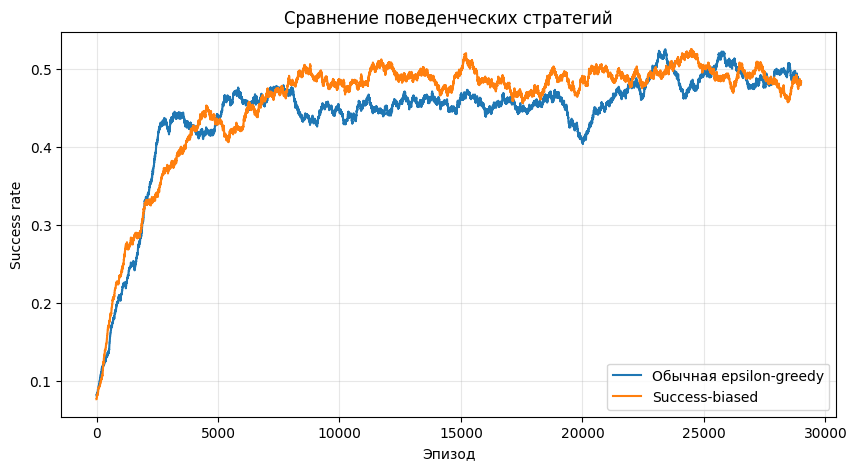

In [21]:
# Сравнение обучения

baseline_success_ma = moving_average(
    baseline[
        "successes"
    ]
)


improved_success_ma = moving_average(
    improved[
        "successes"
    ]
)


plt.figure(
    figsize=(
        10,
        5,
    )
)


plt.plot(
    baseline_success_ma,
    label=(
        "Обычная epsilon-greedy"
    ),
)


plt.plot(
    improved_success_ma,
    label=(
        "Success-biased"
    ),
)


plt.xlabel(
    "Эпизод"
)

plt.ylabel(
    "Success rate"
)

plt.title(
    "Сравнение поведенческих стратегий"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.show()

## Вывод

В работе для среды `Taxi` использован алгоритм
**First-Visit Monte-Carlo Control**.

Сначала агент обучался с обычной `е-greedy` стратегией.
После обучения были выведены несколько полных эпизодов со следующими данными:

```text
state
action
reward
next_state
```

Затем была собрана статистика действий в успешных эпизодах.

Главный вывод по действиям:

- `Dropoff` напрямую приводит к успешному завершению задачи,
  если пассажир доставлен в правильную точку;
- `Pickup` необходим перед перевозкой пассажира;
- движения `South`, `North`, `East`, `West` полезны только
  в зависимости от текущего состояния.

После этого была изменена исследовательская часть `е-greedy`.
При случайном исследовании действия стали выбираться не равномерно,
а с вероятностями, рассчитанными по статистике успешных траекторий.

Обе стратегии затем проверяются на одинаковых новых эпизодах.
Итоговая таблица позволяет сравнить:

```text
средний reward
success rate
```

Численные результаты могут немного отличаться между запусками,
поскольку обучение содержит случайное исследование.